## Ein einfaches Klassifikationsproblem

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

### Generation of Data

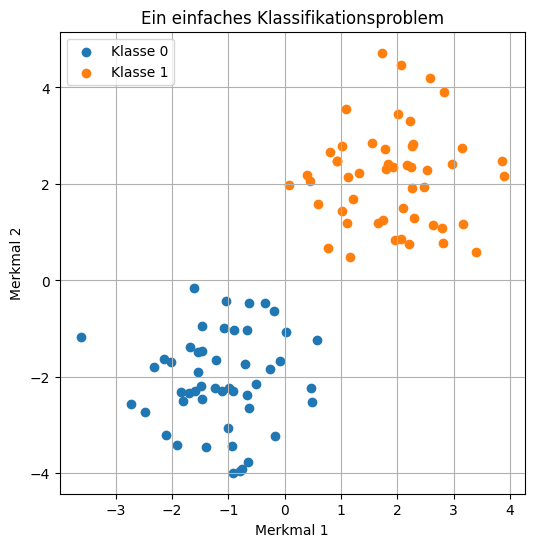

In [9]:
# Zwei Klassen erzeugen

n = 50

# Klasse 0
class0 = np.random.randn(n, 2) + np.array([-1, -2])

# Klasse 1
class1 = np.random.randn(n, 2) + np.array([2, 2])

X = np.vstack([class0, class1])
y = np.hstack([
    np.zeros(n),
    np.ones(n)
])


plt.figure(figsize=(6,6))

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    label="Klasse 0"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    label="Klasse 1"
)

plt.xlabel("Merkmal 1")
plt.ylabel("Merkmal 2")
plt.title("Ein einfaches Klassifikationsproblem")
plt.legend()
plt.grid()

plt.show()

### Perzeptron implementieren

$$z=w_1​x_1​+w_2​x_2​+b$$
$$
y=
\begin{cases}
1,& z>0\\
0,& z\leq0
\end{cases}
$$

oder 

$$ y = f(z) $$

In [10]:
# Hard threshold activation (classical Perzeptron)
def step_activation(z):
    return (z > 0).astype(int)


# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ReLU activation
def relu(z):
    return np.maximum(0, z)


# Hyperbolic tangent
def tanh(z):
    return np.tanh(z)

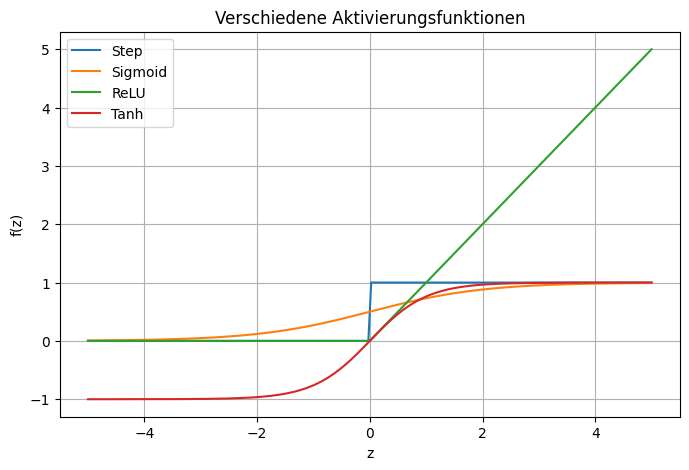

In [11]:
z = np.linspace(-5, 5, 200)


plt.figure(figsize=(8,5))

plt.plot(
    z,
    step_activation(z),
    label="Step"
)

plt.plot(
    z,
    sigmoid(z),
    label="Sigmoid"
)

plt.plot(
    z,
    relu(z),
    label="ReLU"
)

plt.plot(
    z,
    tanh(z),
    label="Tanh"
)


plt.xlabel("z")
plt.ylabel("f(z)")
plt.title("Verschiedene Aktivierungsfunktionen")

plt.grid()
plt.legend()

plt.show()

In [12]:
def predict(X, weights, bias, activation=step_activation):
    
    # weighted sum
    z = X @ weights + bias
    
    # activation function
    return activation(z)

## Vom Perzeptron zum künstlichen Neuron

Alle Varianten berechnen zuerst dieselbe lineare Kombination:

$$
z=\mathbf{w}\cdot\mathbf{x}+b
$$

Der Unterschied liegt nur in der Aktivierungsfunktion:

$$
y=f(z)
$$

Die Aktivierungsfunktion bestimmt, wie das Neuron auf seine Eingabe reagiert.

- Die **Step-Funktion** macht eine harte Entscheidung:
  "Ja oder Nein".

- Die **Sigmoid-Funktion** erzeugt eine Wahrscheinlichkeit:
  "Wie sicher ist das Modell?"

- Die **ReLU-Funktion** lässt positive Signale weiterlaufen und blockiert negative Signale.

Moderne neuronale Netze verwenden meistens ReLU in den versteckten Schichten, weil sie nichtlinear ist und trotzdem einfach berechnet werden kann.

### Training

In [13]:
def train_perceptron(
    X,
    y,
    learning_rate=0.1,
    epochs=20,
    activation=step_activation
):

    n_features = X.shape[1]

    weights = np.random.randn(n_features)
    bias = np.random.randint(-10, 10)

    losses = []

    for epoch in range(epochs):

        total_error = 0

        for xi, yi in zip(X, y):

            prediction = predict(
                xi.reshape(1,-1),
                weights,
                bias,
                activation=activation
            )[0]


            error = yi - prediction


            # Gradient update
            weights += learning_rate * error * xi
            bias += learning_rate * error


            total_error += abs(error)


        losses.append(total_error)


    return weights, bias, losses

### Training starten

In [14]:
learning_rate = 0.1
epochs = 20


weights, bias, losses = train_perceptron(
    X,
    y,
    learning_rate,
    epochs
)


print("Gewichte:")
print(weights)

print("Bias:")
print(bias)

Gewichte:
[4.54252393 4.69624514]
Bias:
-6.500000000000012


### Loss während des Trainings und Entscheidungsgrenze zeichnen

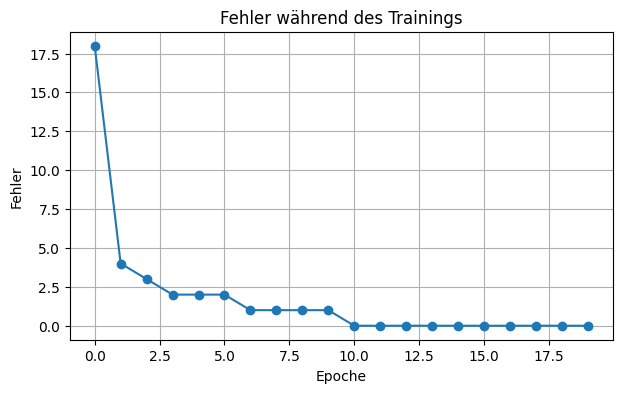

In [15]:
plt.figure(figsize=(7,4))

plt.plot(losses, marker="o")

plt.xlabel("Epoche")
plt.ylabel("Fehler")
plt.title("Fehler während des Trainings")

plt.grid()
plt.show()

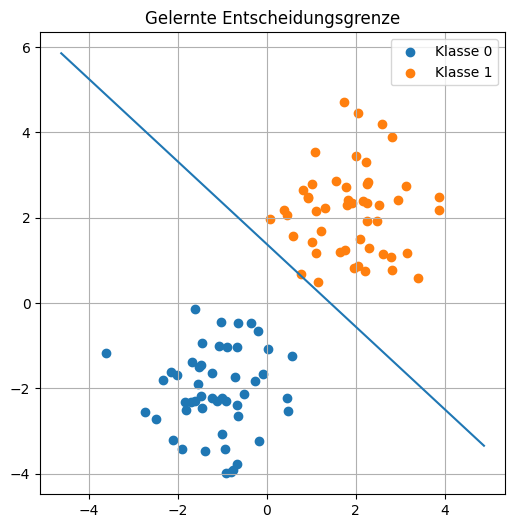

In [16]:
def plot_decision_boundary(X, y, weights, bias):

    plt.figure(figsize=(6,6))

    plt.scatter(
        X[y==0,0],
        X[y==0,1],
        label="Klasse 0"
    )

    plt.scatter(
        X[y==1,0],
        X[y==1,1],
        label="Klasse 1"
    )


    x_values = np.linspace(
        X[:,0].min()-1,
        X[:,0].max()+1,
        100
    )


    # w1*x + w2*y + b = 0
    y_values = (
        -(weights[0]*x_values+bias)
        /weights[1]
    )


    plt.plot(
        x_values,
        y_values
    )


    plt.legend()
    plt.grid()

    plt.title(
        "Gelernte Entscheidungsgrenze"
    )

    plt.show()


plot_decision_boundary(
    X,
    y,
    weights,
    bias
)

### Experiment: Lernrate

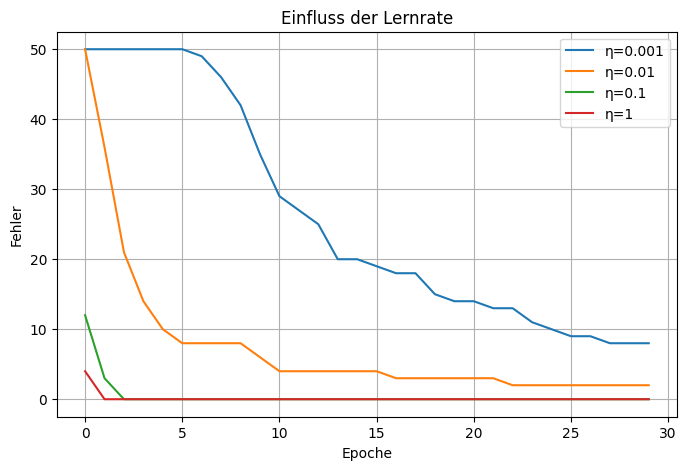

In [17]:
learning_rates = [
    0.001,
    0.01,
    0.1,
    1
]


plt.figure(figsize=(8,5))


for lr in learning_rates:

    _, _, loss = train_perceptron(
        X,
        y,
        learning_rate=lr,
        epochs=30
    )

    plt.plot(
        loss,
        label=f"η={lr}"
    )


plt.xlabel("Epoche")
plt.ylabel("Fehler")

plt.title(
    "Einfluss der Lernrate"
)

plt.legend()
plt.grid()

plt.show()

### Gradient sichtbar machen

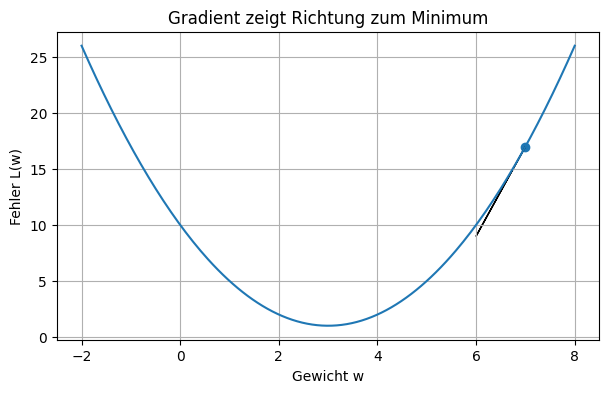

In [18]:
def loss(w):
    return (w-3)**2 + 1


def gradient(w):
    return 2*(w-3)


w_values = np.linspace(-2,8,200)


plt.figure(figsize=(7,4))

plt.plot(
    w_values,
    loss(w_values)
)


w = 7

plt.scatter(
    [w],
    [loss(w)]
)


plt.arrow(
    w,
    loss(w),
    -1,
    -gradient(w),
    length_includes_head=True
)


plt.xlabel("Gewicht w")
plt.ylabel("Fehler L(w)")

plt.title(
    "Gradient zeigt Richtung zum Minimum"
)

plt.grid()

plt.show()

### Ein einzelner Gradient-Schritt

$$
w_{neu}​=w−\eta \frac{\partial w}{\partial L}​ 
$$

In [19]:
w = 7

learning_rate = 0.1

print("Start:")
print(w)


g = gradient(w)


w_new = w - learning_rate*g


print("Gradient:")
print(g)

print("Neues Gewicht:")
print(w_new)

Start:
7
Gradient:
8
Neues Gewicht:
6.2
